In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

# Configure plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5) # Smaller default plots

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Exploratory Data Analysis (EDA)

In [4]:
# Load datasets
train_df = "/content/customer_churn_dataset-training-master.csv"
test_df = "/content/customer_churn_dataset-testing-master.csv"
df_train = pd.read_csv(train_df, encoding='ascii', delimiter=',')
df_test = pd.read_csv(test_df, encoding='ascii', delimiter=',')

df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

print('\nCombined Data Shape:', df.shape)

df.head()


Combined Data Shape: (126232, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30,Female,39,14,5,18,Standard,Annual,932.0,17.0,1.0
1,3,65,Female,49,1,10,8,Basic,Monthly,557.0,6.0,1.0
2,4,55,Female,14,4,6,18,Basic,Quarterly,185.0,3.0,1.0
3,5,58,Male,38,21,7,7,Standard,Monthly,396.0,29.0,1.0
4,6,23,Male,32,20,5,8,Basic,Monthly,617.0,20.0,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126232 entries, 0 to 126231
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         126232 non-null  int64  
 1   Age                126232 non-null  int64  
 2   Gender             126232 non-null  object 
 3   Tenure             126232 non-null  int64  
 4   Usage Frequency    126232 non-null  int64  
 5   Support Calls      126232 non-null  int64  
 6   Payment Delay      126232 non-null  int64  
 7   Subscription Type  126232 non-null  object 
 8   Contract Length    126231 non-null  object 
 9   Total Spend        126231 non-null  float64
 10  Last Interaction   126231 non-null  float64
 11  Churn              126231 non-null  float64
dtypes: float64(3), int64(6), object(3)
memory usage: 11.6+ MB


In [6]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,126232.000000,126232.000000,126232.000000,126232.000000,126232.000000,126232.000000,126231.000000,126231.000000,126231.000000
mean,31728.732865,41.773916,31.239004,15.270850,5.238759,16.136701,544.092164,15.523271,0.721075
std,18415.258945,13.916976,17.239484,8.754946,3.138529,8.961251,260.116796,8.640232,0.448472
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,15783.750000,30.000000,16.000000,8.000000,3.000000,8.000000,318.000000,8.000000,0.000000
50%,31562.500000,42.000000,32.000000,15.000000,5.000000,17.000000,540.000000,16.000000,1.000000
75%,47664.250000,54.000000,46.000000,23.000000,8.000000,24.000000,770.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [7]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,1
Total Spend,1


In [8]:
df = df.dropna()

In [9]:
# Percentage of Churned Customers and not Churned Customers
100*df['Churn'].value_counts()/len(df['Churn'])

,count
Churn,
1.0,72.107485
0.0,27.892515


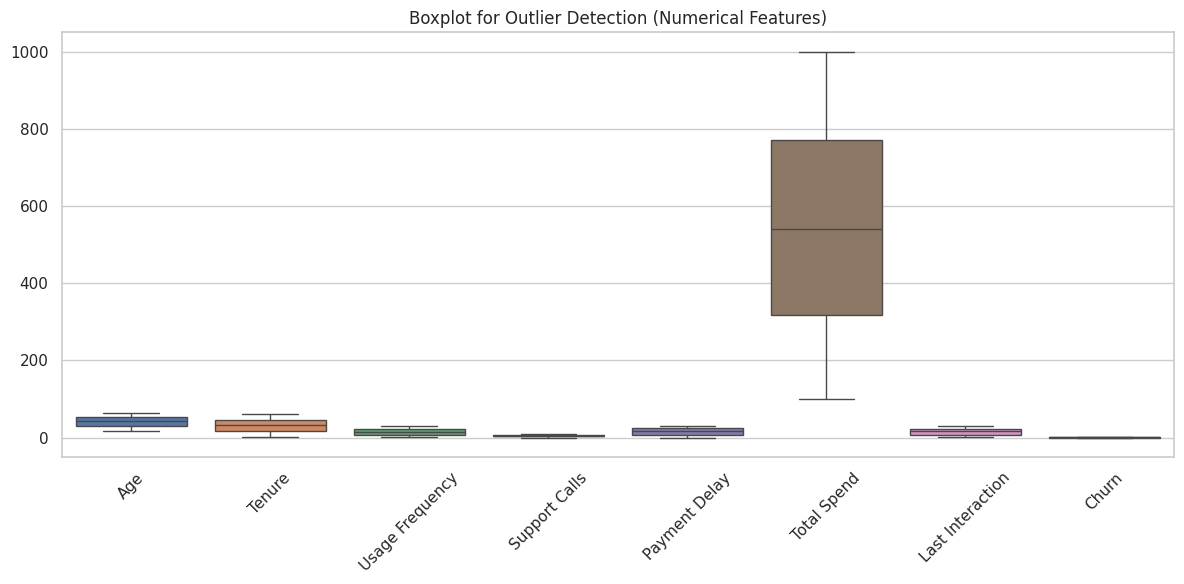

In [10]:
# Drop non-numerical columns + improve boxplot display
outlier_df = df.drop(['CustomerID', 'Gender', 'Subscription Type', 'Contract Length'], axis=1)

plt.figure(figsize=(12, 6))
sns.boxplot(data=outlier_df)
plt.xticks(rotation=45)
plt.title('Boxplot for Outlier Detection (Numerical Features)')
plt.tight_layout()
plt.show()


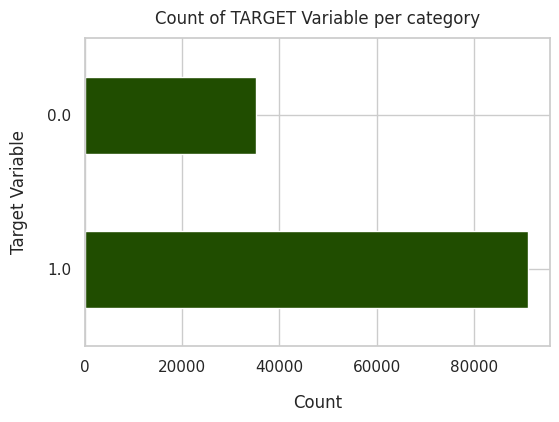

In [11]:
# Checking Balanced or Imbalanced Dataset
df['Churn'].value_counts().plot(kind='barh', color="#204D00", figsize=(6, 4))
plt.xlabel("Count", labelpad=14)
plt.ylabel("Target Variable", labelpad=14)
plt.title("Count of TARGET Variable per category", y=1.02);

In [12]:
# Checking which feature/column should be converted into Bins
for column in df.columns:
    print(f'{column} =>', df[column].value_counts().shape)

CustomerID => (64374,)
Age => (48,)
Gender => (2,)
Tenure => (60,)
Usage Frequency => (30,)
Support Calls => (11,)
Payment Delay => (31,)
Subscription Type => (3,)
Contract Length => (3,)
Total Spend => (901,)
Last Interaction => (30,)
Churn => (2,)


In [13]:
max_val = int(df['Tenure'].max())
min_val = int(df['Tenure'].min())

labels = ["{0} - {1}".format(i, i + 11) for i in range(min_val, max_val, 12)]
df['tenure_group'] = pd.cut(df_train.Tenure, range(min_val, max_val + 10, 12), right=False, labels=labels)

df['tenure_group'].value_counts()


,count
tenure_group,
13 - 24,12449
37 - 48,12431
1 - 12,12412
49 - 60,12314
25 - 36,12251


In [14]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,tenure_group
0,2,30,Female,39,14,5,18,Standard,Annual,932.0,17.0,1.0,37 - 48
1,3,65,Female,49,1,10,8,Basic,Monthly,557.0,6.0,1.0,49 - 60
2,4,55,Female,14,4,6,18,Basic,Quarterly,185.0,3.0,1.0,13 - 24
3,5,58,Male,38,21,7,7,Standard,Monthly,396.0,29.0,1.0,37 - 48
4,6,23,Male,32,20,5,8,Basic,Monthly,617.0,20.0,1.0,25 - 36


In [15]:
# Dropping CustomerID Column
df.drop(['CustomerID'], axis=1, inplace=True)

In [16]:
max_val = int(df['Age'].max())
min_val = int(df['Age'].min())

labels = ["{0} - {1}".format(i, i + 11) for i in range(min_val, max_val, 12)]
df['Age_group'] = pd.cut(df_train['Age'], range(min_val, max_val + 12, 12), right=False, labels=labels)

df['Age_group'].value_counts()


,count
Age_group,
54 - 65,15767
18 - 29,15586
42 - 53,15292
30 - 41,15212


In [17]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,tenure_group,Age_group
0,30,Female,39,14,5,18,Standard,Annual,932.0,17.0,1.0,37 - 48,30 - 41
1,65,Female,49,1,10,8,Basic,Monthly,557.0,6.0,1.0,49 - 60,54 - 65
2,55,Female,14,4,6,18,Basic,Quarterly,185.0,3.0,1.0,13 - 24,54 - 65
3,58,Male,38,21,7,7,Standard,Monthly,396.0,29.0,1.0,37 - 48,54 - 65
4,23,Male,32,20,5,8,Basic,Monthly,617.0,20.0,1.0,25 - 36,18 - 29


## Advanced Analysis

In [18]:
# set our charts' colors
color = ["#00876c", "#6b9c72", "#a3b088", "#cec6ad", "#cda376", "#d37755", "#d43d51"]

<ipython-input-19-df2a6e83e633>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Age_group", palette=color)
<ipython-input-19-df2a6e83e633>:2: UserWarning: The palette list has more values (7) than needed (4), which may not be intended.
  sns.countplot(data=df, x="Age_group", palette=color)


<Axes: xlabel='Age_group', ylabel='count'>

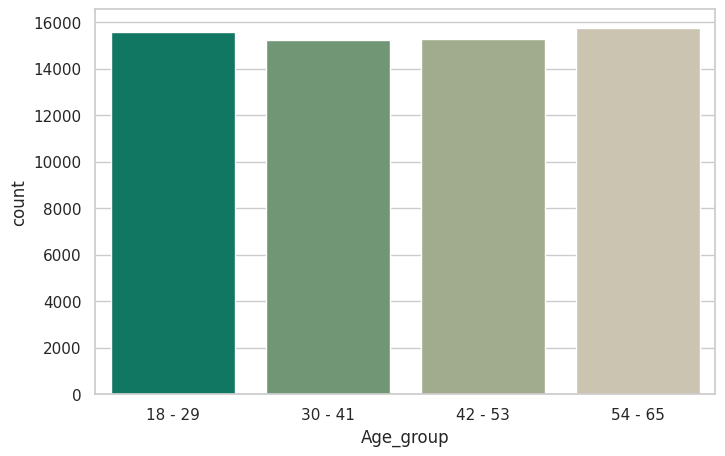

In [19]:
# Univariate Analysis of Age Column
sns.countplot(data=df, x="Age_group", palette=color)

<ipython-input-20-043ddc01ff98>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Usage Frequency", palette=color)
<ipython-input-20-043ddc01ff98>:3: UserWarning: 
The palette list has fewer values (7) than needed (30) and will cycle, which may produce an uninterpretable plot.
  ax = sns.countplot(data=df, x="Usage Frequency", palette=color)


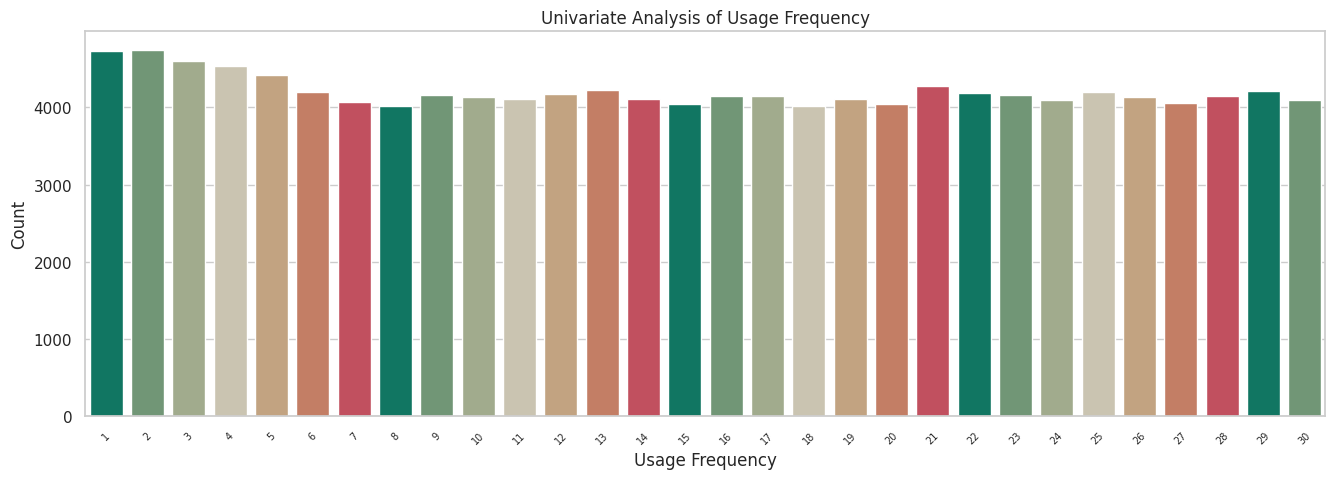

In [20]:
# Univariate Analysis of Usage Frequency
plt.figure(figsize=(16,5))
ax = sns.countplot(data=df, x="Usage Frequency", palette=color)
plt.xticks(rotation =45,fontsize =7)
plt.title("Univariate Analysis of Usage Frequency")
plt.ylabel("Count")
plt.show()

<ipython-input-21-977b30b51436>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="tenure_group", palette=color)
<ipython-input-21-977b30b51436>:3: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  ax = sns.countplot(data=df, x="tenure_group", palette=color)


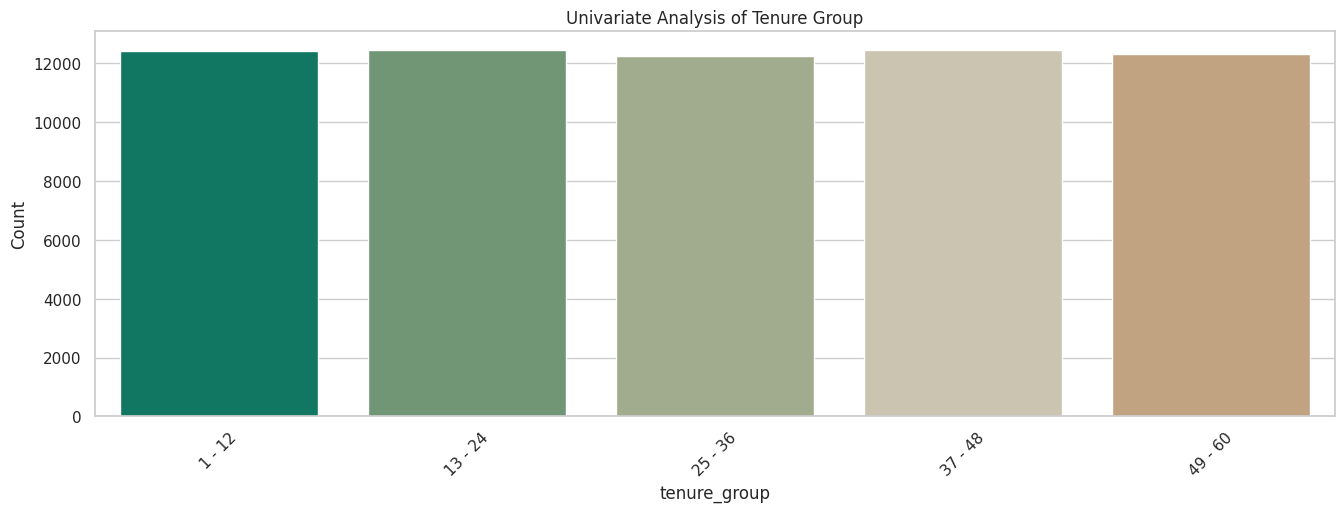

In [21]:
# Univariate Analysis of Tenure
plt.figure(figsize=(16,5))
ax = sns.countplot(data=df, x="tenure_group", palette=color)
plt.xticks(rotation =45)
plt.title("Univariate Analysis of Tenure Group")
plt.ylabel("Count")
plt.show()

<ipython-input-22-a497c0e476b1>:3: UserWarning: The palette list has more values (7) than needed (2), which may not be intended.
  sns.countplot(data=df, x=predictor, hue='Churn', palette=color)
<ipython-input-22-a497c0e476b1>:3: UserWarning: The palette list has more values (7) than needed (2), which may not be intended.
  sns.countplot(data=df, x=predictor, hue='Churn', palette=color)
<ipython-input-22-a497c0e476b1>:3: UserWarning: The palette list has more values (7) than needed (2), which may not be intended.
  sns.countplot(data=df, x=predictor, hue='Churn', palette=color)
<ipython-input-22-a497c0e476b1>:3: UserWarning: The palette list has more values (7) than needed (2), which may not be intended.
  sns.countplot(data=df, x=predictor, hue='Churn', palette=color)
<ipython-input-22-a497c0e476b1>:3: UserWarning: The palette list has more values (7) than needed (2), which may not be intended.
  sns.countplot(data=df, x=predictor, hue='Churn', palette=color)
<ipython-input-22-a497c0e

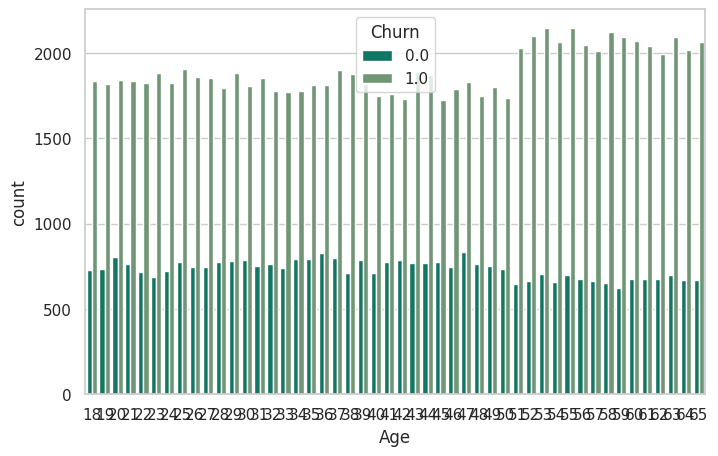

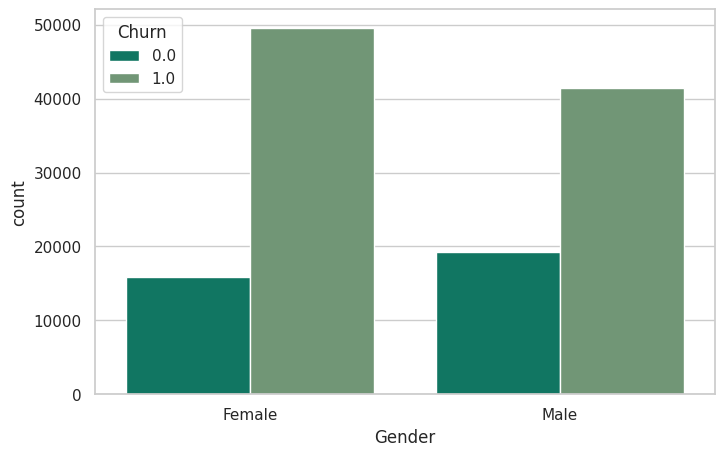

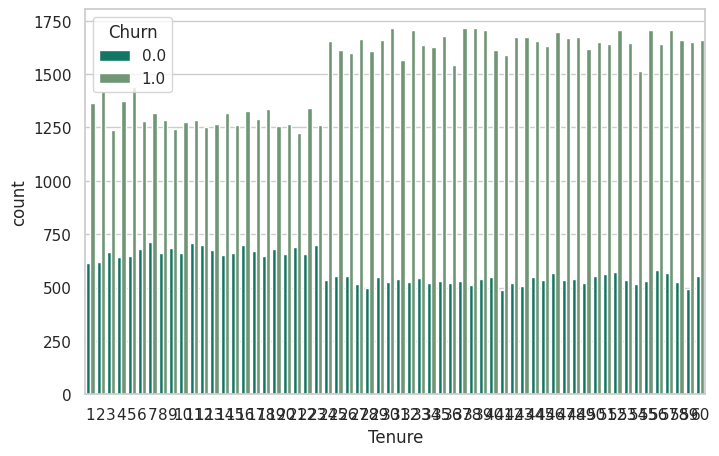

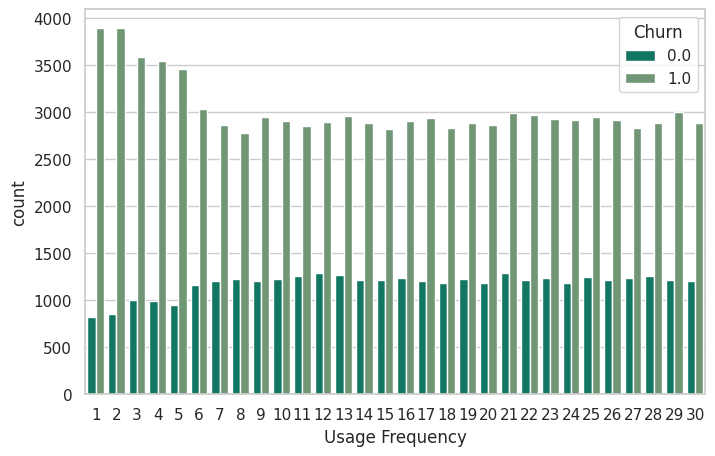

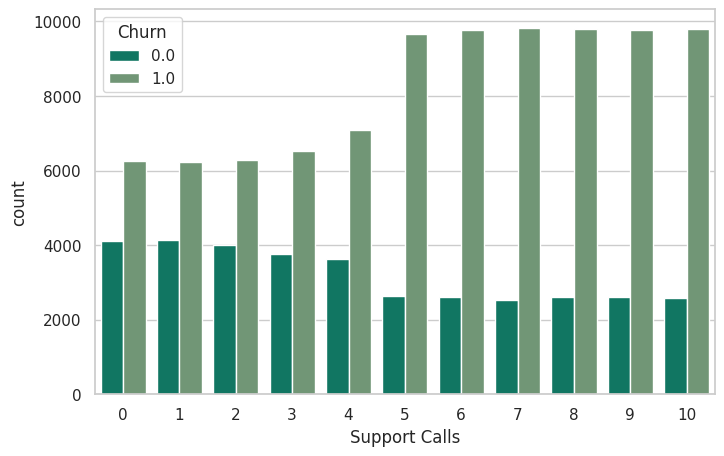

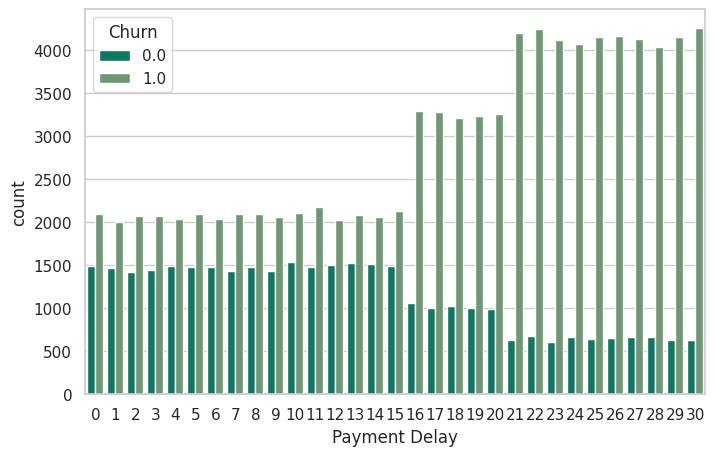

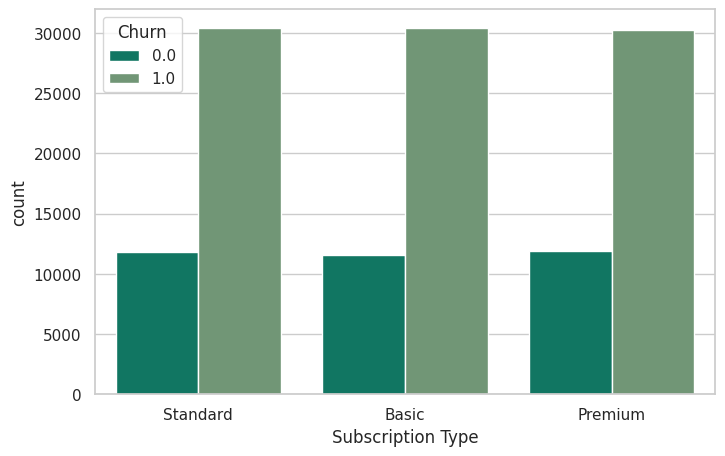

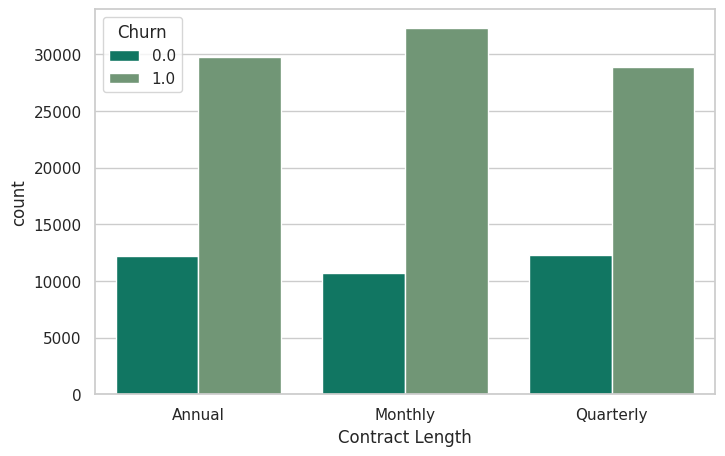

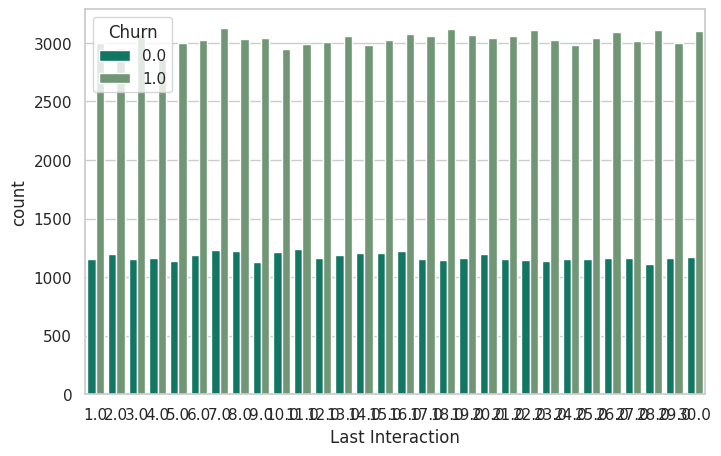

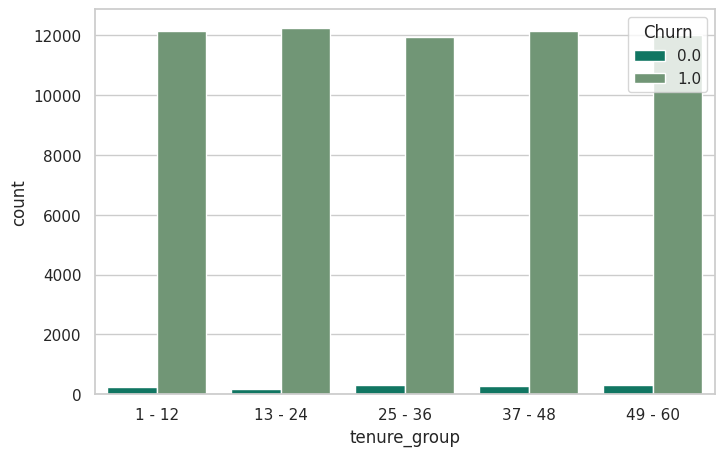

In [22]:
for i, predictor in enumerate(df.drop(columns=['Churn', 'Total Spend', 'Age_group'])):
    plt.figure(i)
    sns.countplot(data=df, x=predictor, hue='Churn', palette=color)

<ipython-input-23-ab9b44e0521d>:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df["Total Spend"][(df["Churn"] == 0)],
<ipython-input-23-ab9b44e0521d>:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df["Total Spend"][(df["Churn"] == 1)],


Text(0.5, 1.0, 'Total Spend by churn')

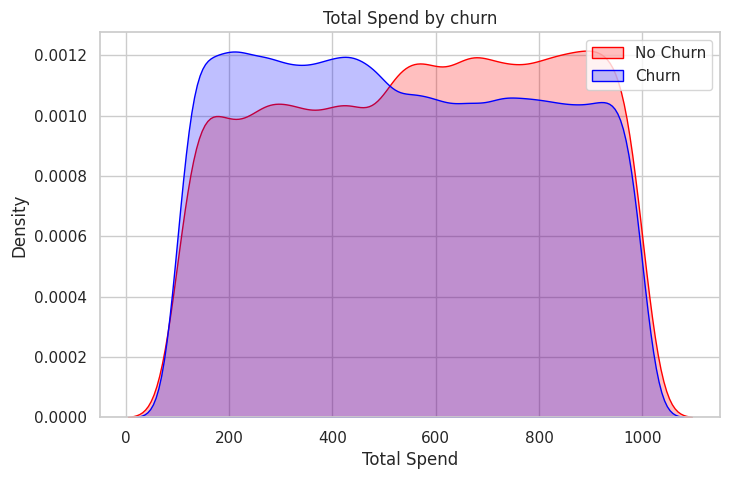

In [23]:
# Bivariate Analysis of Total Spend by using KDE
Tot = sns.kdeplot(df["Total Spend"][(df["Churn"] == 0)],
                color="Red", shade = True)
Tot = sns.kdeplot(df["Total Spend"][(df["Churn"] == 1)],
                ax =Tot, color="Blue", shade= True)
Tot.legend(["No Churn","Churn"],loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Total Spend')
Tot.set_title('Total Spend by churn')

<ipython-input-24-89a9f1d86c87>:3: UserWarning: The palette list has more values (7) than needed (2), which may not be intended.
  ax = sns.countplot(data=df, x="Payment Delay", hue='Churn', palette=color)


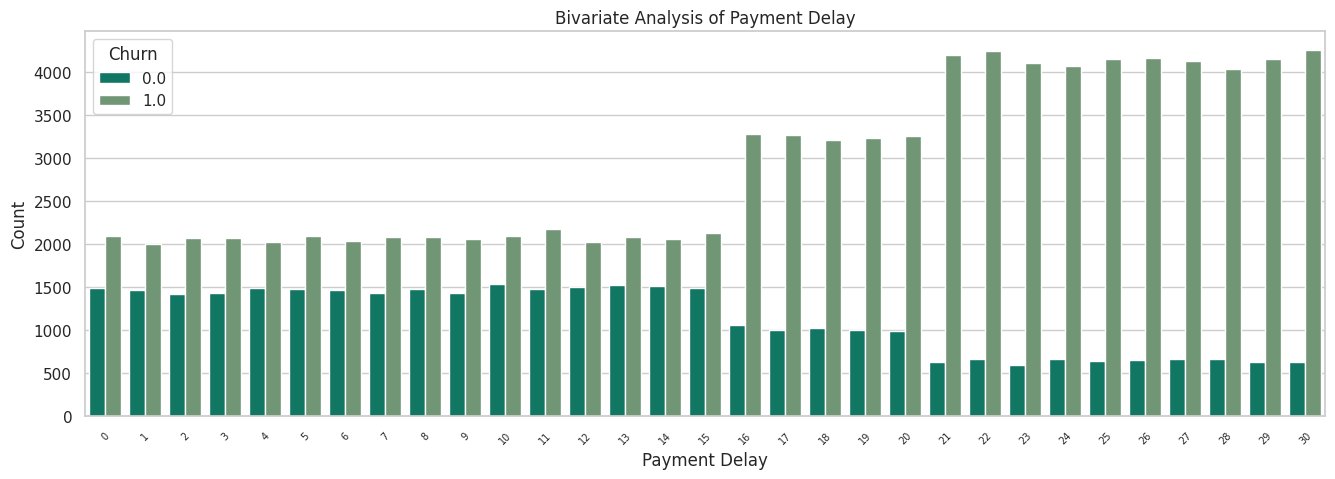

In [24]:
# Biivariate Analysis of Payment Delay
plt.figure(figsize=(16,5))
ax = sns.countplot(data=df, x="Payment Delay", hue='Churn', palette=color)
plt.xticks(rotation =45,fontsize =7)
plt.title("Bivariate Analysis of Payment Delay")
plt.ylabel("Count")
plt.show()

## Feature Engineering

In [25]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

##### New features added:


In [26]:
# Example of feature engineering in the training set
X_train['Log_Usage_Rate'] = np.log1p(X_train['Usage Frequency'] / (X_train['Last Interaction'] + 1e-6))
X_train['Spend_Per_Usage'] = X_train['Total Spend'] / X_train['Usage Frequency']
X_train['Payment_Delay_Ratio'] = X_train['Payment Delay'] / X_train['Last Interaction']

# Customer Segmentation (uses statistics from training set only)
high_value_threshold = X_train['Total Spend'].quantile(0.75)
payment_delay_median = X_train['Payment Delay'].median()
support_calls_median = X_train['Support Calls'].median()

X_train['High_Value'] = ((X_train['Total Spend'] > high_value_threshold) &
                         (X_train['Payment Delay'] < payment_delay_median)).astype(int)

X_train['At_Risk'] = ((X_train['Support Calls'] > support_calls_median) &
                      (X_train['Payment Delay'] > payment_delay_median)).astype(int)

# Binning (Grouping continuous features into categories)
age_bins = [0, 25, 45, 65, 100]
tenure_bins = [0, 12, 24, 36, 48, 60]

X_train['Age_group'] = pd.cut(X_train['Age'], bins=age_bins, labels=['Young', 'Adult', 'Senior', 'Elder'])
X_train['tenure_group'] = pd.cut(X_train['Tenure'], bins=tenure_bins, labels=['<1yr', '1-2yr', '2-3yr', '3-4yr', '4-5yr'])


In [27]:
# Apply the same operations to the test set
X_test['Log_Usage_Rate'] = np.log1p(X_test['Usage Frequency'] / (X_test['Last Interaction'] + 1e-6))
X_test['Spend_Per_Usage'] = X_test['Total Spend'] / X_test['Usage Frequency']
X_test['Payment_Delay_Ratio'] = X_test['Payment Delay'] / X_test['Last Interaction']

# Use the same thresholds and statistics from the training set
X_test['High_Value'] = ((X_test['Total Spend'] > high_value_threshold) &
                        (X_test['Payment Delay'] < payment_delay_median)).astype(int)

X_test['At_Risk'] = ((X_test['Support Calls'] > support_calls_median) &
                     (X_test['Payment Delay'] > payment_delay_median)).astype(int)

# Use the same bin ranges as in the training set
X_test['Age_group'] = pd.cut(X_test['Age'], bins=age_bins, labels=['Young', 'Adult', 'Senior', 'Elder'])
X_test['tenure_group'] = pd.cut(X_test['Tenure'], bins=tenure_bins, labels=['<1yr', '1-2yr', '2-3yr', '3-4yr', '4-5yr'])


In [28]:
X_train['Spend_Per_Usage'] = X_train['Spend_Per_Usage'].replace([np.inf, -np.inf], np.nan).fillna(0)
X_test['Spend_Per_Usage'] = X_test['Spend_Per_Usage'].replace([np.inf, -np.inf], np.nan).fillna(0)

In [29]:
X_train['Spend_Per_Usage'] = X_train['Spend_Per_Usage'].replace([np.inf, -np.inf], np.nan).fillna(X_train['Spend_Per_Usage'].median())
X_test['Spend_Per_Usage'] = X_test['Spend_Per_Usage'].replace([np.inf, -np.inf], np.nan).fillna(X_train['Spend_Per_Usage'].median())

In [30]:
from sklearn.preprocessing import OneHotEncoder
import joblib

# Identify categorical columns automatically
cat_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

# Create the OneHotEncoder with sparse_output set to False
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Apply encoding to the data
X_train_encoded = ohe.fit_transform(X_train[cat_cols])
X_test_encoded = ohe.transform(X_test[cat_cols])

# Convert the encoded arrays back into DataFrames with proper column names
cat_columns = ohe.get_feature_names_out(cat_cols)
X_train_encoded = pd.DataFrame(X_train_encoded, columns=cat_columns, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=cat_columns, index=X_test.index)

# Save the encoder using joblib
joblib.dump(ohe, r"F:\Downloads\One_Hot_Encoder.pkl")

['F:\\Downloads\\One_Hot_Encoder.pkl']

In [31]:
X_train_encoded = pd.DataFrame(X_train_encoded, columns=cat_columns, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=cat_columns, index=X_test.index)

X_train_final = pd.concat([X_train.drop(cat_cols, axis=1), X_train_encoded], axis=1)
X_test_final = pd.concat([X_test.drop(cat_cols, axis=1), X_test_encoded], axis=1)

In [32]:
num_cols = X_train.select_dtypes(exclude=['object', 'category', 'string']).columns.tolist()


scaler = StandardScaler()

X_train_final[num_cols] = scaler.fit_transform(X_train_final[num_cols])
X_test_final[num_cols] = scaler.transform(X_test_final[num_cols])

joblib.dump(scaler, r"F:\Downloads\standard_scaler.pkl")

['F:\\Downloads\\standard_scaler.pkl']

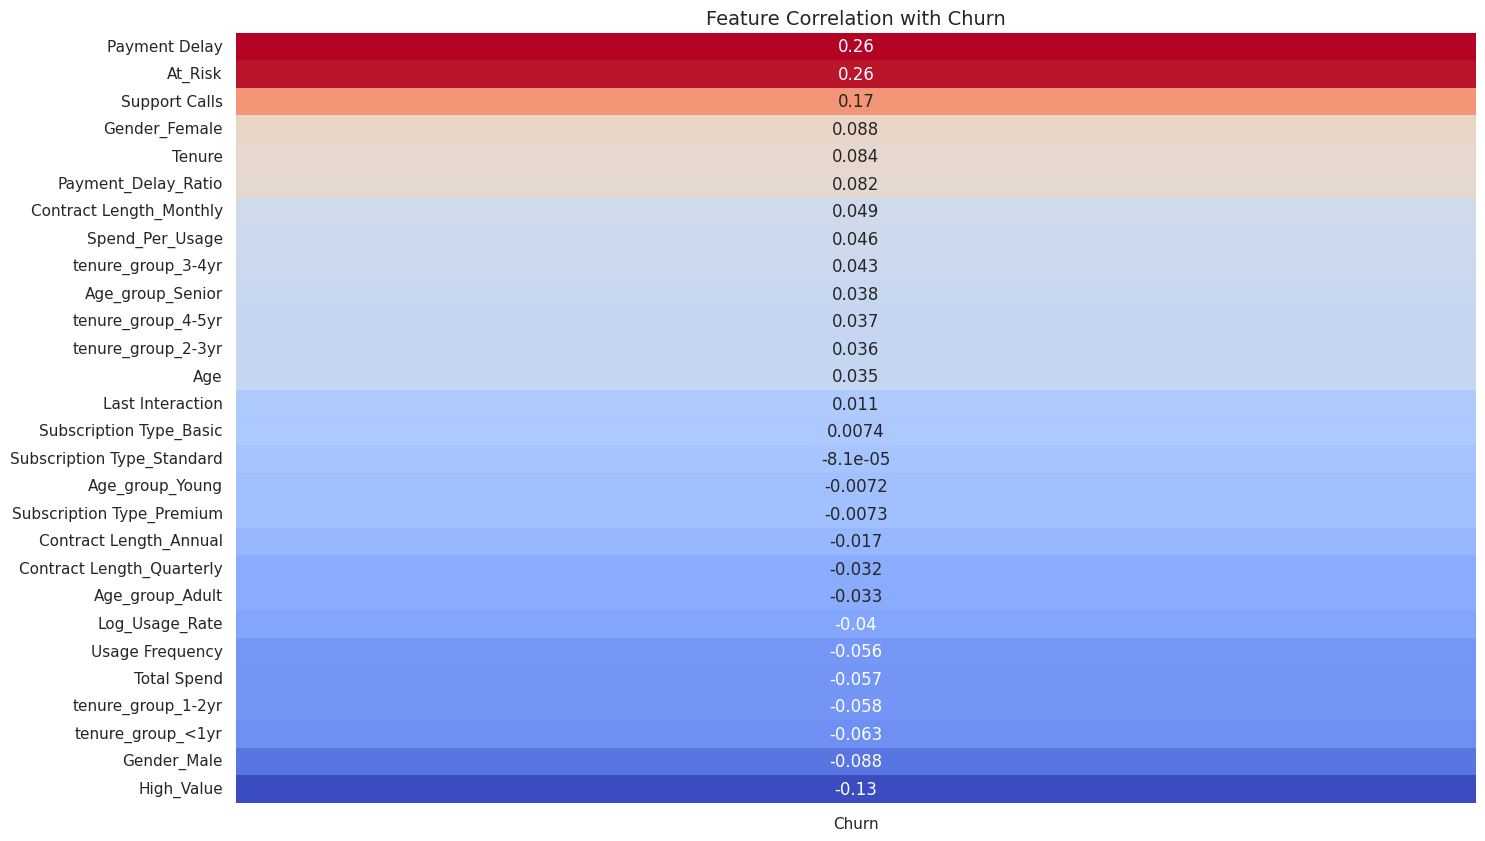


Top Features Correlated with Churn:
Payment Delay                 0.262585
At_Risk                       0.255356
Support Calls                 0.169426
Gender_Female                 0.088279
Tenure                        0.083512
Payment_Delay_Ratio           0.081671
Contract Length_Monthly       0.048686
Spend_Per_Usage               0.046029
tenure_group_3-4yr            0.043467
Age_group_Senior              0.037924
tenure_group_4-5yr            0.036900
tenure_group_2-3yr            0.036263
Age                           0.035156
Last Interaction              0.010563
Subscription Type_Basic       0.007423
Subscription Type_Standard   -0.000081
Age_group_Young              -0.007173
Subscription Type_Premium    -0.007333
Contract Length_Annual       -0.016938
Contract Length_Quarterly    -0.032280
Age_group_Adult              -0.032734
Log_Usage_Rate               -0.040393
Usage Frequency              -0.055604
Total Spend                  -0.056729
tenure_group_1-2yr         

In [33]:
# Temporarily add the target 'Churn' to the features to calculate correlation
X_with_target = X_train_final.copy()
X_with_target['Churn'] = y_train

# Calculate correlation with 'Churn' only (remove self-correlation)
churn_correlation = X_with_target.corr()['Churn'].drop('Churn')

# Sort features by their correlation with 'Churn' (descending order)
churn_correlation_sorted = churn_correlation.sort_values(ascending=False)

# Plot heatmap of top correlated features with Churn
plt.figure(figsize=(16, 10))
sns.heatmap(churn_correlation_sorted.to_frame(), annot=True, cmap='coolwarm', cbar=False)
plt.title("Feature Correlation with Churn", fontsize=14)
plt.show()

# Print sorted correlations
print("\nTop Features Correlated with Churn:")
print(churn_correlation_sorted)

In [34]:
import joblib

# Save the statistics used during training
stats = {
    'spend_75th': X_train['Total Spend'].quantile(0.75),          # 75th percentile for Total Spend
    'payment_delay_median': X_train['Payment Delay'].median(),    # Median of Payment Delay
    'support_calls_median': X_train['Support Calls'].median(),    # Median of Support Calls
    'age_bins': [0, 25, 45, 65, 100],                              # Bin edges for Age_group
    'tenure_bins': [0, 12, 24, 36, 48, 60]                         # Bin edges for tenure_group
}

# Save the stats dictionary to a file
# Save the stats dictionary to a file
joblib.dump(stats, r'F:\Downloads\feature_engineering_stats (1).pkl')


['F:\\Downloads\\feature_engineering_stats (1).pkl']

In [35]:
# Load the saved statistics
stats = joblib.load(r'F:\Downloads\feature_engineering_stats (1).pkl')
def create_features(df, stats):
    # Create new features using the same logic
    df['Log_Usage_Rate'] = np.log1p(df['Usage Frequency'] / (df['Last Interaction'] + 1e-6))
    df['Spend_Per_Usage'] = df['Total Spend'] / df['Usage Frequency']
    df['Payment_Delay_Ratio'] = df['Payment Delay'] / df['Last Interaction']

    # Use the saved statistics
    df['High_Value'] = ((df['Total Spend'] > stats['spend_75th']) &
                        (df['Payment Delay'] < stats['payment_delay_median'])).astype(int)

    df['At_Risk'] = ((df['Support Calls'] > stats['support_calls_median']) &
                     (df['Payment Delay'] > stats['payment_delay_median'])).astype(int)

    # Binning using the same thresholds
    df['Age_group'] = pd.cut(df['Age'], bins=stats['age_bins'], labels=['Young', 'Adult', 'Senior', 'Elder'])
    df['tenure_group'] = pd.cut(df['Tenure'], bins=stats['tenure_bins'], labels=['<1yr', '1-2yr', '2-3yr', '3-4yr', '4-5yr'])

    return df

## Tips About ML

#### (X_train_final and y_train)
are used to train the model

#### (X_test_final and y_test)
are used to evaluate the model after training

### Loading preprocessing objects

ohe = joblib.load('onehot_encoder.pkl')  # Load the OneHotEncoder for categorical data encoding

scaler = joblib.load('standard_scaler.pkl')  # Load the StandardScaler for normalizing numerical data

### Applying OneHotEncoder to the categorical columns
new_cat_data = ohe.transform(new_data_processed[cat_cols])  # Transform categorical data using the encoder

new_cat_df = pd.DataFrame(new_cat_data, columns=ohe.get_feature_names_out(cat_cols), index=new_data_processed.index)  

### Create a DataFrame from the transformed categorical data, keeping the same index as the original data

### Merging the numerical and categorical data
new_num_data = new_data_processed[num_cols]  # Extract the numerical data columns

new_final = pd.concat([new_num_data, new_cat_df], axis=1)  # Combine numerical and categorical data into one DataFrame

### Applying StandardScaler to the numerical data
new_final[num_cols] = scaler.transform(new_final[num_cols])  # Scale the numerical features

In [36]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import lightgbm as lgb
import xgboost as xgb
import re

In [37]:

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42 , class_weight='balanced')
print("\nبدء تدريب النموذج...")
model.fit(X_train_final, y_train)



بدء تدريب النموذج...


RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [38]:
# =====================
# 6. تقييم النموذج
# =====================
def evaluate_model(model, X_test, y_test):
    """تقييم أداء النموذج"""
    # التنبؤات
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # نتائج التقييم
    print("\n" + "="*50)
    print("تقرير التصنيف:")
    print(classification_report(y_test, y_pred))

    print("\nمصفوفة الارتباك:")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('prediction')
    plt.ylabel('Truth')
    plt.title('Evaluation Matrix')
    plt.show()

    print(f"\nAUC Score: {roc_auc_score(y_test, y_proba):.2f}")
    print("="*50 + "\n")

In [39]:
# =====================
# 7. حفظ النموذج
# =====================
def save_model(model, file_path):
    """حفظ النموذج للاستخدام المستقبلي"""
    joblib.dump(model, file_path)
    print(f"تم حفظ النموذج في {file_path}")


تقرير التصنيف:
              precision    recall  f1-score   support

         0.0       0.44      0.87      0.59      7077
         1.0       0.92      0.57      0.71     18170

    accuracy                           0.66     25247
   macro avg       0.68      0.72      0.65     25247
weighted avg       0.79      0.66      0.67     25247


مصفوفة الارتباك:


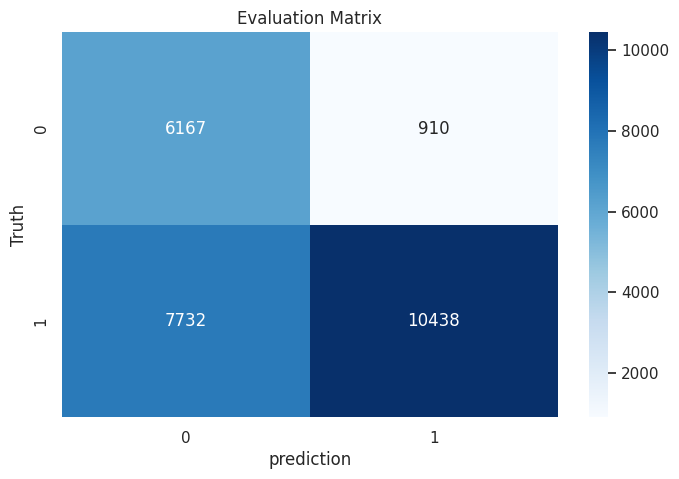


AUC Score: 0.77

تم حفظ النموذج في best_churn_model.pkl


In [40]:

evaluate_model(model, X_test_final, y_test)
save_model(model, 'best_churn_model.pkl')


In [41]:
# 2. تدريب وتقييم LightGBM
def train_evaluate_lightgbm(X_train, y_train, X_test, y_test):
    # تدريب النموذج
    lgbm = lgb.LGBMClassifier(
        random_state=42,
        class_weight='balanced',
        n_estimators=150,
        learning_rate=0.05,
        verbosity=-1
    )
    lgbm.fit(X_train, y_train)

    # التنبؤ والتقييم
    y_pred = lgbm.predict(X_test)
    y_proba = lgbm.predict_proba(X_test)[:,1]

    print("\n" + "="*50)
    print("LightGBM Evaluation")
    print("="*50)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('LightGBM Confusion Matrix')
    plt.show()

    print(f"\nAUC Score: {roc_auc_score(y_test, y_proba):.2f}")

    return lgbm

In [42]:
# 3. تدريب وتقييم XGBoost

def clean_feature_names(df):
    """تنظيف أسماء الميزات من الأحرف غير المسموح بها"""
    df.columns = [re.sub(r'[\[\]<>]', '', col) for col in df.columns]
    return df


def train_evaluate_xgboost(X_train, y_train, X_test, y_test):
    X_train = clean_feature_names(pd.DataFrame(X_train))
    X_test = clean_feature_names(pd.DataFrame(X_test))

    # حساب وزن الفئة للأقلية
    scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)

    # تدريب النموذج
    xgb_model = xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        n_estimators=150,
        learning_rate=0.05,
        eval_metric='aucpr',
        use_label_encoder=False
    )
    xgb_model.fit(X_train, y_train)

    # التنبؤ والتقييم
    y_pred = xgb_model.predict(X_test)
    y_proba = xgb_model.predict_proba(X_test)[:,1]

    print("\n" + "="*50)
    print("XGBoost Evaluation")
    print("="*50)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('XGBoost Confusion Matrix')
    plt.show()

    print(f"\nAUC Score: {roc_auc_score(y_test, y_proba):.2f}")

    return xgb_model

Training LightGBM Model...

LightGBM Evaluation

Classification Report:
              precision    recall  f1-score   support

         0.0       0.44      0.99      0.61      7077
         1.0       1.00      0.52      0.68     18170

    accuracy                           0.65     25247
   macro avg       0.72      0.76      0.65     25247
weighted avg       0.84      0.65      0.66     25247


Confusion Matrix:


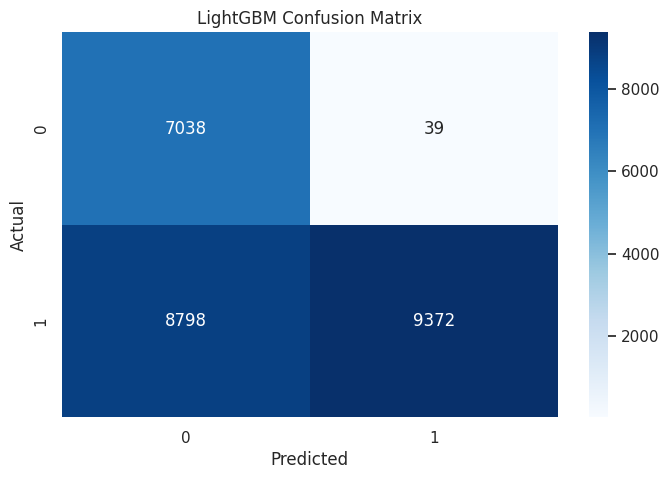


AUC Score: 0.78


In [43]:
# 4. التنفيذ
print("Training LightGBM Model...")
lgbm_model = train_evaluate_lightgbm(X_train_final, y_train, X_test_final, y_test)




Training XGBoost Model...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:50:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Evaluation

Classification Report:
              precision    recall  f1-score   support

         0.0       0.44      0.99      0.61      7077
         1.0       0.99      0.52      0.68     18170

    accuracy                           0.65     25247
   macro avg       0.72      0.75      0.65     25247
weighted avg       0.84      0.65      0.66     25247


Confusion Matrix:


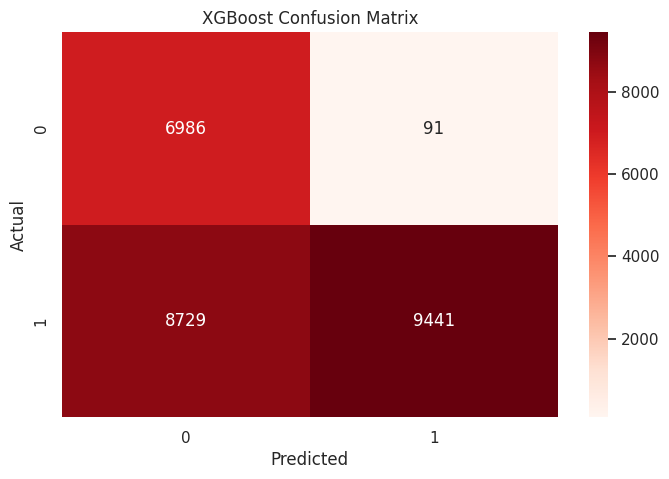


AUC Score: 0.78


In [44]:
print("\nTraining XGBoost Model...")
xgb_model = train_evaluate_xgboost(X_train_final, y_train, X_test_final, y_test)

In [45]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn', 'tenure_group', 'Age_group'],
      dtype='object')

In [ ]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 20.2 MB/s eta 0:00:00


In [46]:
import pandas as pd
import numpy as np

# إنشاء بيانات تجريبية
np.random.seed(42)  # للتكرارية
num_samples = 505206  # عدد العينات (يمكن تقليله للاختبار)

data = {
    'Age': np.clip(np.random.normal(35, 10, num_samples), 18, 70).astype(float),
    'Gender': np.random.choice(['Male', 'Female', 'Non-binary'], num_samples, p=[0.45, 0.45, 0.1]),
    'Tenure': np.clip(np.random.gamma(shape=2, scale=6, size=num_samples), 1, 60).astype(float),
    'Usage Frequency': np.clip(np.random.poisson(15, num_samples), 1, 30).astype(float),
    'Support Calls': np.random.poisson(2, num_samples).astype(float),
    'Payment Delay': np.clip(np.random.exponential(5, num_samples), 0, 30).astype(float),
    'Subscription Type': np.random.choice(['Basic', 'Standard', 'Premium'], num_samples, p=[0.5, 0.3, 0.2]),
    'Contract Length': np.random.choice(['Monthly', 'Quarterly', 'Annual'], num_samples, p=[0.6, 0.2, 0.2]),
    'Total Spend': np.clip(np.random.normal(1000, 400, num_samples), 100, 5000).astype(float),
    'Last Interaction': np.clip(np.random.exponential(5, num_samples), 1, 30).astype(float),
}

# إنشاء الـ DataFrame
df2 = pd.DataFrame(data)

# إنشاء عمود Churn بناءً على شروط واقعية
df2['Churn'] = (
    (df2['Payment Delay'] > 10) |
    (df2['Support Calls'] > 3) |
    (df2['Contract Length'] == 'Monthly') & (df['Tenure'] < 6) |
    (df2['Total Spend'] < 500)
).astype(float)

# إضافة الأعمدة الفئوية المشتقة
df2['tenure_group'] = pd.cut(
    df['Tenure'],
    bins=[0, 12, 24, float('inf')],
    labels=['Short', 'Medium', 'Long']
).astype('category')

max_val = int(df['Age'].max())
min_val = int(df['Age'].min())

labels = ["{0} - {1}".format(i, i + 11) for i in range(min_val, max_val, 12)]
df2['Age_group'] = pd.cut(df2['Age'], range(min_val, max_val + 12, 12), right=False, labels=labels)

df2['Age_group'].value_counts()

# تصدير إلى CSV
df2.to_csv('churn_data_test.csv', index=False)

# عرض معلومات البيانات
print("تم إنشاء الملف بنجاح!")
print("\nمعلومات DataFrame:")
print(df2.info())
print("\nعينة من البيانات:")
print(df2.head())

تم إنشاء الملف بنجاح!

معلومات DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505206 entries, 0 to 505205
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   Age                505206 non-null  float64 
 1   Gender             505206 non-null  object  
 2   Tenure             505206 non-null  float64 
 3   Usage Frequency    505206 non-null  float64 
 4   Support Calls      505206 non-null  float64 
 5   Payment Delay      505206 non-null  float64 
 6   Subscription Type  505206 non-null  object  
 7   Contract Length    505206 non-null  object  
 8   Total Spend        505206 non-null  float64 
 9   Last Interaction   505206 non-null  float64 
 10  Churn              505206 non-null  float64 
 11  tenure_group       126231 non-null  category
 12  Age_group          504760 non-null  category
dtypes: category(2), float64(8), object(3)
memory usage: 43.4+ MB
None

عينة من البيانات:
       

In [47]:
df2


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,tenure_group,Age_group
0,39.967142,Female,12.931147,14.0,6.0,4.793374,Premium,Annual,1107.880281,12.027998,1.0,Long,30 - 41
1,33.617357,Female,9.137040,10.0,3.0,1.546230,Basic,Monthly,1329.824538,12.922671,0.0,Long,30 - 41
2,41.476885,Male,12.642116,17.0,2.0,5.836149,Basic,Monthly,1052.865364,7.052630,0.0,Medium,30 - 41
3,50.230299,Male,25.696168,14.0,2.0,0.663392,Basic,Monthly,990.090394,5.919975,0.0,Long,42 - 53
4,32.658466,Female,6.694146,14.0,5.0,1.563249,Standard,Monthly,1352.364039,3.200019,1.0,Long,30 - 41
...,...,...,...,...,...,...,...,...,...,...,...,...,...
505201,18.000000,Male,11.715901,18.0,2.0,3.554319,Basic,Monthly,950.755546,9.101761,0.0,NaN,18 - 29
505202,35.928831,Male,20.633229,12.0,0.0,4.645207,Basic,Quarterly,1337.583069,14.583255,0.0,NaN,30 - 41
505203,45.189891,Male,8.799815,21.0,4.0,7.208449,Standard,Monthly,1024.964970,5.271738,1.0,NaN,42 - 53
505204,38.894469,Female,7.656561,16.0,1.0,1.191674,Standard,Monthly,717.483731,6.531569,0.0,NaN,30 - 41


In [48]:
# Separate features and target
x = df2.drop('Churn', axis=1)
y = df2['Churn']

In [49]:
# Example of feature engineering in the training set
x['Log_Usage_Rate'] = np.log1p(x['Usage Frequency'] / (x['Last Interaction'] + 1e-6))
x['Spend_Per_Usage'] = x['Total Spend'] / x['Usage Frequency']
x['Payment_Delay_Ratio'] = x['Payment Delay'] / x['Last Interaction']

# Customer Segmentation (uses statistics from training set only)
high_value_threshold = x['Total Spend'].quantile(0.75)
payment_delay_median = x['Payment Delay'].median()
support_calls_median = x['Support Calls'].median()

x['High_Value'] = ((x['Total Spend'] > high_value_threshold) &
                         (x['Payment Delay'] < payment_delay_median)).astype(int)

x['At_Risk'] = ((x['Support Calls'] > support_calls_median) &
                      (x['Payment Delay'] > payment_delay_median)).astype(int)

# Binning (Grouping continuous features into categories)
age_bins = [0, 25, 45, 65, 100]
tenure_bins = [0, 12, 24, 36, 48, 60]

x['Age_group'] = pd.cut(x['Age'], bins=age_bins, labels=['Young', 'Adult', 'Senior', 'Elder'])
x['tenure_group'] = pd.cut(x['Tenure'], bins=tenure_bins, labels=['<1yr', '1-2yr', '2-3yr', '3-4yr', '4-5yr'])

x

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,tenure_group,Age_group,Log_Usage_Rate,Spend_Per_Usage,Payment_Delay_Ratio,High_Value,At_Risk
0,39.967142,Female,12.931147,14.0,6.0,4.793374,Premium,Annual,1107.880281,12.027998,1-2yr,Adult,0.771936,79.134306,0.398518,0,1
1,33.617357,Female,9.137040,10.0,3.0,1.546230,Basic,Monthly,1329.824538,12.922671,<1yr,Adult,0.573143,132.982454,0.119653,1,0
2,41.476885,Male,12.642116,17.0,2.0,5.836149,Basic,Monthly,1052.865364,7.052630,1-2yr,Adult,1.226844,61.933257,0.827514,0,0
3,50.230299,Male,25.696168,14.0,2.0,0.663392,Basic,Monthly,990.090394,5.919975,2-3yr,Senior,1.213391,70.720742,0.112060,0,0
4,32.658466,Female,6.694146,14.0,5.0,1.563249,Standard,Monthly,1352.364039,3.200019,<1yr,Adult,1.681753,96.597431,0.488512,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505201,18.000000,Male,11.715901,18.0,2.0,3.554319,Basic,Monthly,950.755546,9.101761,<1yr,Young,1.091131,52.819753,0.390509,0,0
505202,35.928831,Male,20.633229,12.0,0.0,4.645207,Basic,Quarterly,1337.583069,14.583255,1-2yr,Adult,0.600408,111.465256,0.318530,0,0
505203,45.189891,Male,8.799815,21.0,4.0,7.208449,Standard,Monthly,1024.964970,5.271738,<1yr,Senior,1.606134,48.807856,1.367376,0,1
505204,38.894469,Female,7.656561,16.0,1.0,1.191674,Standard,Monthly,717.483731,6.531569,<1yr,Adult,1.238270,44.842733,0.182448,0,0


In [50]:
x['Spend_Per_Usage'] = x['Spend_Per_Usage'].replace([np.inf, -np.inf], np.nan).fillna(0)
x['Spend_Per_Usage'] = x['Spend_Per_Usage'].replace([np.inf, -np.inf], np.nan).fillna(x['Spend_Per_Usage'].median())


In [51]:
ohe = joblib.load('/content/F:\Downloads\One_Hot_Encoder.pkl')  # Load the OneHotEncoder for categorical data encoding

scaler = joblib.load('/content/F:\Downloads\standard_scaler.pkl')  # Load the StandardScaler for normalizing numerical data

In [52]:
### Applying OneHotEncoder to the categorical columns
new_cat_data = ohe.transform(df2[cat_cols])  # Transform categorical data using the encoder

new_cat_df = pd.DataFrame(new_cat_data, columns=ohe.get_feature_names_out(cat_cols), index=df2.index)

In [53]:
### Merging the numerical and categorical data
new_num_data = x[num_cols]  # Extract the numerical data columns

new_final_x = pd.concat([new_num_data, new_cat_df], axis=1)  # Combine numerical and categorical data into one DataFrame

### Applying StandardScaler to the numerical data
new_final_x[num_cols] = scaler.transform(new_final_x[num_cols])  # Scale the numerical features

In [54]:
new_final_x

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Log_Usage_Rate,Spend_Per_Usage,Payment_Delay_Ratio,...,Contract Length_Monthly,Contract Length_Quarterly,tenure_group_1-2yr,tenure_group_2-3yr,tenure_group_3-4yr,tenure_group_4-5yr,tenure_group_<1yr,Age_group_Adult,Age_group_Senior,Age_group_Young
0,-0.130251,-1.061555,-0.147084,0.240431,-1.263606,2.169202,-0.404510,-0.094718,0.024915,-0.473380,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.586863,-1.281542,-0.604262,-0.715689,-1.625678,3.022364,-0.301032,-0.410453,0.454548,-0.549354,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.021685,-1.078313,0.195799,-1.034396,-1.147331,1.957723,-0.979961,0.627795,-0.112326,-0.356505,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.607771,-0.321422,-0.147084,-1.034396,-1.724119,1.716413,-1.110964,0.606428,-0.042214,-0.551422,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.655816,-1.423184,-0.147084,-0.078275,-1.623781,3.109007,-1.425555,1.350311,0.164246,-0.448862,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505201,-1.709904,-1.132016,0.310094,-1.034396,-1.401767,1.565209,-0.742959,0.412247,-0.185039,-0.475562,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
505202,-0.420645,-0.614978,-0.375673,-1.671810,-1.280127,3.052188,-0.108969,-0.367150,0.282870,-0.495172,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
505203,0.245316,-1.301095,0.652977,-0.396982,-0.994313,1.850472,-1.185939,1.230207,-0.217048,-0.209426,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
505204,-0.207387,-1.367382,0.081505,-1.353103,-1.665213,0.668503,-1.040227,0.645943,-0.248684,-0.532246,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
# التنبؤ بالاحتمالات (للحصول على AUC-ROC)
y_pred_proba = lgbm_model.predict_proba(new_final_x)[:, 1]

# التنبؤ بالفئات (للحصول على الدقة وغيرها)
y_pred = lgbm_model.predict(new_final_x)


XGBoost Evaluation

Classification Report:
              precision    recall  f1-score   support

         0.0       0.66      0.99      0.79    330584
         1.0       0.71      0.05      0.09    174622

    accuracy                           0.66    505206
   macro avg       0.68      0.52      0.44    505206
weighted avg       0.68      0.66      0.55    505206


Confusion Matrix:


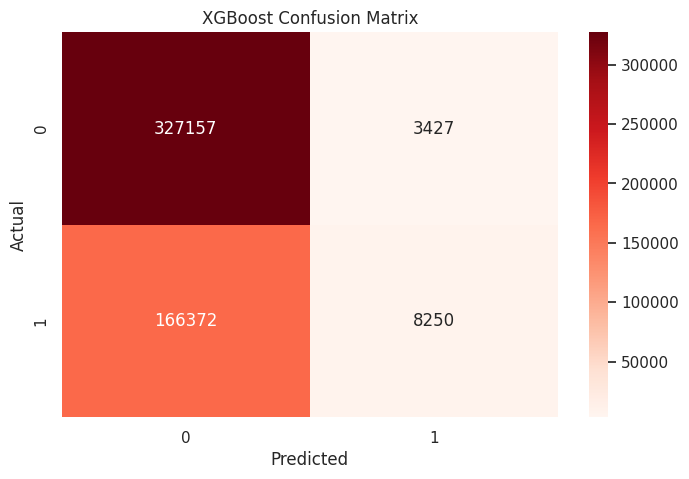


AUC Score: 0.66


In [56]:
 #  التقييم
print("\n" + "="*50)
print("XGBoost Evaluation")
print("="*50)
print("\nClassification Report:")
print(classification_report(y, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()

print(f"\nAUC Score: {roc_auc_score(y, y_pred_proba):.2f}")


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

#define random forest model
rf_model = RandomForestClassifier(random_state=42)

#Identify the hyperparameters to be tested
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

#Create a Grid Search object
grid_search = GridSearchCV(
    estimator= rf_model,
    param_grid= param_grid,
    scoring = 'roc_auc',
    cv = 5,
    n_jobs=-1,
    verbose=2
)

#train grid search
grid_search.fit(X_train_final, y_train)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'],
                         'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc', verbose=2)

In [ ]:
# view the best AUC and parameters
print("best AUC:", grid_search.best_score_)
print("Best barameters:", grid_search.best_params_)


best AUC: 0.9533682970956745
Best barameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
# testing test data
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test_final)
y_pred_proba = best_rf.predict_proba(X_test_final)[:, 1]


In [ ]:
print("\n Classification Report:")
print(classification_report(y_test, y_pred))


 Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.86      0.92     44952
         1.0       0.90      1.00      0.94     56090

    accuracy                           0.93    101042
   macro avg       0.95      0.93      0.93    101042
weighted avg       0.94      0.93      0.93    101042




 Confusion Matrix:


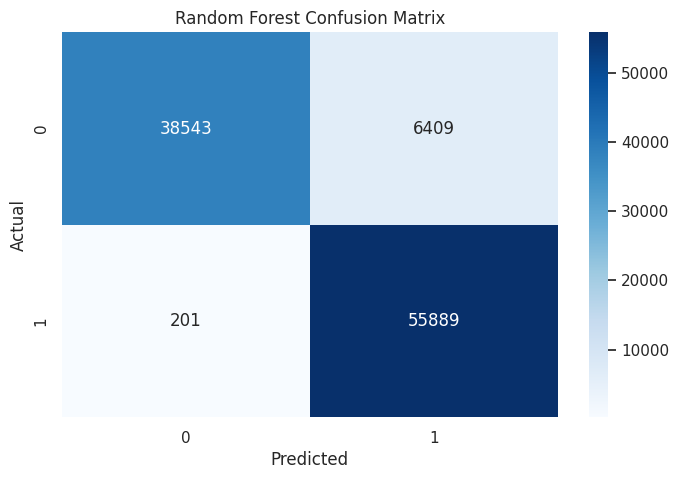


 AUC Score: 0.953


In [ ]:
print("\n Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

print(f"\n AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")

In [ ]:
# testing new data
best_rf = grid_search.best_estimator_
y_pred_new = best_rf.predict(new_final_x)
y_pred_proba_new = best_rf.predict_proba(new_final_x)[:, 1]

In [ ]:
#Classification Report for new data
print("\n Classification Report:")
print(classification_report(y, y_pred_new))


 Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.36      0.51    319684
         1.0       0.45      0.88      0.59    185522

    accuracy                           0.55    505206
   macro avg       0.64      0.62      0.55    505206
weighted avg       0.70      0.55      0.54    505206




 Confusion Matrix:


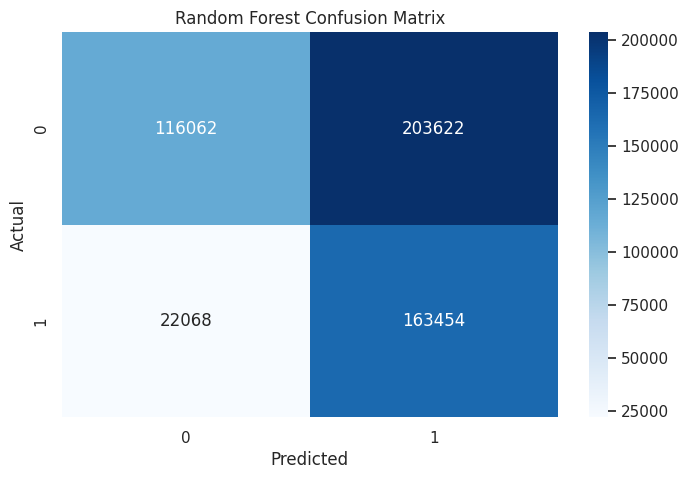


 AUC Score: 0.654


In [ ]:
#Confusion Matrix for new data
print("\n Confusion Matrix:")
cm = confusion_matrix(y, y_pred_new)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

print(f"\n AUC Score: {roc_auc_score(y, y_pred_proba_new):.3f}")

In [58]:
pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 20.8 MB/s eta 0:00:00


In [ ]:
import optuna
import lightgbm as lgb


# Definition of the objective function of Optuna
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'feature_pre_filter': False,
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 16, 256),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    }

    dtrain = lgb.Dataset(X_train_final, label=y_train)
    dvalid = lgb.Dataset(X_test_final, label=y_test)

    model = lgb.train(
      params,
      dtrain,
      num_boost_round=500,
      valid_sets=[dvalid],
      valid_names=['valid'],
      callbacks=[lgb.early_stopping(stopping_rounds=50),
                 lgb.log_evaluation(period=0) ]
        )


    preds = model.predict(X_test_final)
    auc = roc_auc_score(y_test, preds)
    return auc

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2025-05-05 22:03:55,035] A new study created in memory with name: no-name-e1d60417-d3c3-42b7-ae5c-31b23fd18063


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[171]	valid's auc: 0.953148


[I 2025-05-05 22:04:09,491] Trial 0 finished with value: 0.953147933775108 and parameters: {'lambda_l1': 4.5933932857959405, 'lambda_l2': 0.0008612925197686178, 'num_leaves': 25, 'feature_fraction': 0.9243139351443533, 'bagging_fraction': 0.8805316483772231, 'bagging_freq': 1, 'min_child_samples': 51}. Best is trial 0 with value: 0.953147933775108.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[79]	valid's auc: 0.953065


[I 2025-05-05 22:04:23,546] Trial 1 finished with value: 0.9530650573939989 and parameters: {'lambda_l1': 0.0675817939581597, 'lambda_l2': 0.23981173452135798, 'num_leaves': 85, 'feature_fraction': 0.5603660366022577, 'bagging_fraction': 0.7465024430576107, 'bagging_freq': 5, 'min_child_samples': 71}. Best is trial 0 with value: 0.953147933775108.


...

[I 2025-05-05 22:14:45,209] Trial 47 finished with value: 0.9540256842892676 and parameters: {'lambda_l1': 2.3221158878527707e-07, 'lambda_l2': 1.1335059568001014e-07, 'num_leaves': 243, 'feature_fraction': 0.9795843916534237, 'bagging_fraction': 0.9252135976779575, 'bagging_freq': 5, 'min_child_samples': 52}. Best is trial 42 with value: 0.954388792628581.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[31]	valid's auc: 0.954107


[I 2025-05-05 22:14:56,255] Trial 48 finished with value: 0.954107082895117 and parameters: {'lambda_l1': 3.966237258772941e-06, 'lambda_l2': 0.04129508020171543, 'num_leaves': 209, 'feature_fraction': 0.9571989615693195, 'bagging_fraction': 0.8420859093842703, 'bagging_freq': 7, 'min_child_samples': 70}. Best is trial 42 with value: 0.954388792628581.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[43]	valid's auc: 0.953766


[I 2025-05-05 22:15:08,263] Trial 49 finished with value: 0.9537663289803453 and parameters: {'lambda_l1': 3.305821045791193e-08, 'lambda_l2': 0.013468541991232569, 'num_leaves': 210, 'feature_fraction': 0.8792790283834712, 'bagging_fraction': 0.8420516979734698, 'bagging_freq': 7, 'min_child_samples': 73}. Best is trial 42 with value: 0.954388792628581.


In [ ]:
print("best AUC:", study.best_value)
print("best parameters:", study.best_params)

best AUC: 0.954388792628581
best parameters: {'lambda_l1': 1.2212112242130098e-06, 'lambda_l2': 3.3924759873531295e-08, 'num_leaves': 214, 'feature_fraction': 0.9488807558519815, 'bagging_fraction': 0.7243819862456452, 'bagging_freq': 6, 'min_child_samples': 44}


In [ ]:
best_params = study.best_params
best_params.update({
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'verbosity': -1
})

#train mode with best parameters
dtrain_final = lgb.Dataset(X_train_final, label=y_train)
final_model = lgb.train(
    best_params,
    dtrain_final,
    num_boost_round=study.best_trial.number
)


📊 Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.86      0.92     44952
         1.0       0.90      1.00      0.95     56090

    accuracy                           0.94    101042
   macro avg       0.95      0.93      0.93    101042
weighted avg       0.94      0.94      0.94    101042


📊 Confusion Matrix:


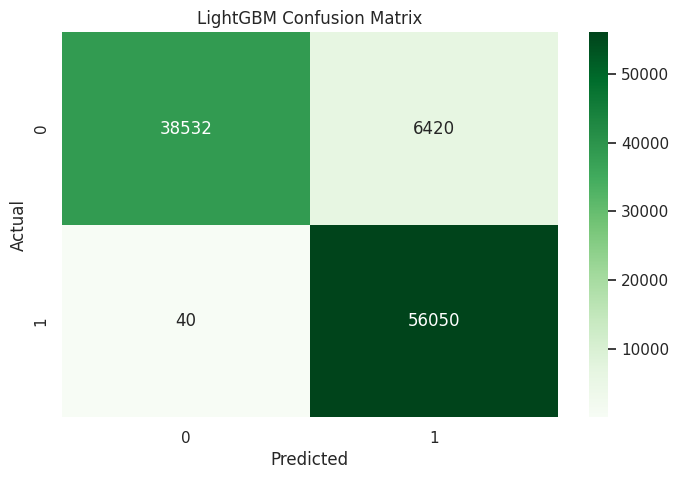


📈 Final AUC Score: 0.954


In [ ]:
# testing test data
y_pred = final_model.predict(X_test_final)
y_pred_class = (y_pred >= 0.5).astype(int)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_class))

print("\n📊 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Confusion Matrix")
plt.show()

print(f"\n📈 Final AUC Score: {roc_auc_score(y_test, y_pred):.3f}")



📊 Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.31      0.45    319684
         1.0       0.43      0.90      0.58    185522

    accuracy                           0.52    505206
   macro avg       0.64      0.60      0.52    505206
weighted avg       0.69      0.52      0.50    505206


📊 Confusion Matrix:


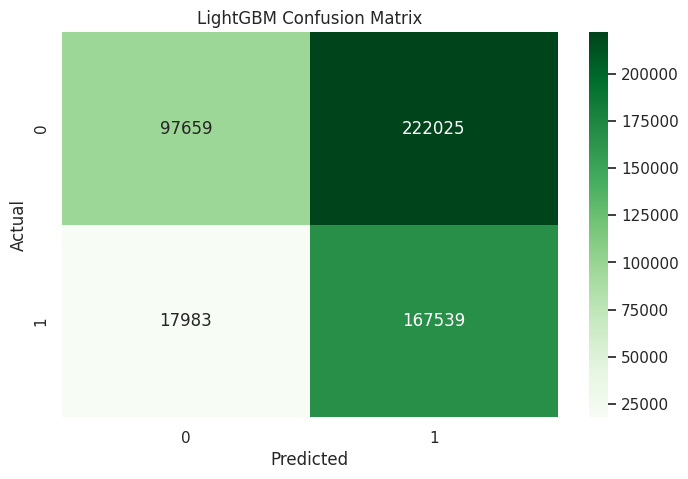


📈 Final AUC Score: 0.582


In [ ]:
# testing new data
y_pred2 = final_model.predict(new_final_x)
y_pred_class = (y_pred2 >= 0.5).astype(int)

print("\n📊 Classification Report:")
print(classification_report(y, y_pred_class))

print("\n📊 Confusion Matrix:")
cm = confusion_matrix(y, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Confusion Matrix")
plt.show()

print(f"\n📈 Final AUC Score: {roc_auc_score(y, y_pred2):.3f}")

In [59]:
import optuna
from xgboost import XGBClassifier, callback

In [60]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'use_label_encoder': False,
        'eval_metric': 'auc',
        'random_state': 42
    }

    model = XGBClassifier(**params)

    model.fit(
        X_train_final,
        y_train,
        eval_set=[(X_test_final, y_test)],
        callbacks=[callback.EarlyStopping(rounds=50)],
        verbose=False
    )

    preds = model.predict_proba(X_test_final)[:, 1]
    auc = roc_auc_score(y_test, preds)
    return auc


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

[I 2025-05-08 20:54:30,853] A new study created in memory with name: no-name-d937e190-5bf0-4c55-909f-275f8d41ba58
[W 2025-05-08 20:54:30,880] Trial 0 failed with parameters: {'n_estimators': 224, 'max_depth': 6, 'learning_rate': 0.06743702479080492, 'subsample': 0.7962266406004213, 'colsample_bytree': 0.6495987764322682, 'gamma': 2.227358303552748, 'reg_alpha': 0.07072737376561483, 'reg_lambda': 6.704181234767637} because of the following error: TypeError("XGBClassifier.fit() got an unexpected keyword argument 'callbacks'").
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "<ipython-input-60-022a700ee695>", line 18, in objective
    model.fit(
  File "/usr/local/lib/python3.11/dist-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
TypeError: XGBClassifier.fit() got an unexpected

TypeError: XGBClassifier.fit() got an unexpected keyword argument 'callbacks'

In [73]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [76]:
def clean_feature_names(df):
    df.columns = [re.sub(r'[\[\]<>]', '', col) for col in df.columns]
    return df

In [79]:
#define random search function
def train_evaluate_xgboost_random_search(X_train, y_train):
    X_train = clean_feature_names(pd.DataFrame(X_train))


    #define XGBBOOST model
    model = XGBClassifier(use_label_encoder=False, eval_metric='auc', random_state=42)


    #Specify the search range for each hyperparamete
    param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5, 10],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.1, 0.5, 1, 5]
    }


    #Random Search
    random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    return random_search

In [81]:
#evaluate random search
random_search_xgboost = train_evaluate_xgboost_random_search(X_train_final,y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [23:37:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [82]:
print("✅ Best Parameters Found:")
print(random_search_xgboost.best_params_)

✅ Best Parameters Found:
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}


In [84]:
# testing test data
best_xbgboost_model = random_search_xgboost.best_estimator_
y_pred_proba = best_xbgboost_model.predict_proba(clean_feature_names(pd.DataFrame(X_test_final)))[:, 1]
y_pred_class = (y_pred_proba >= 0.5).astype(int)


📊 Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.10      0.17      7077
         1.0       0.74      0.99      0.85     18170

    accuracy                           0.74     25247
   macro avg       0.80      0.54      0.51     25247
weighted avg       0.77      0.74      0.66     25247



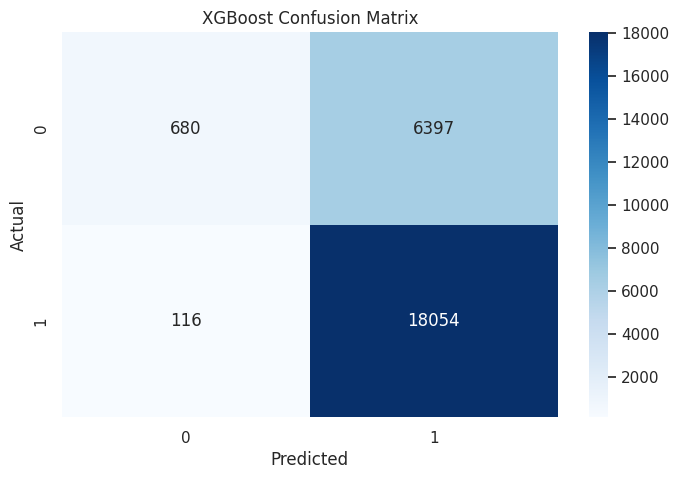


📈 ROC AUC: 0.7766336708658566


In [96]:
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_class))


cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

print("\n📈 ROC AUC:", roc_auc_score(y_test, y_pred_proba))

In [91]:
#testing new data
y_pred_proba_new2 = best_xbgboost_model.predict_proba(clean_feature_names(pd.DataFrame(new_final_x)))[:, 1]
y_pred_class_new2 = (y_pred_proba_new2 >= 0.5).astype(int)


📊 Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.33      0.48    330584
         1.0       0.42      0.91      0.57    174622

    accuracy                           0.53    505206
   macro avg       0.65      0.62      0.52    505206
weighted avg       0.72      0.53      0.51    505206



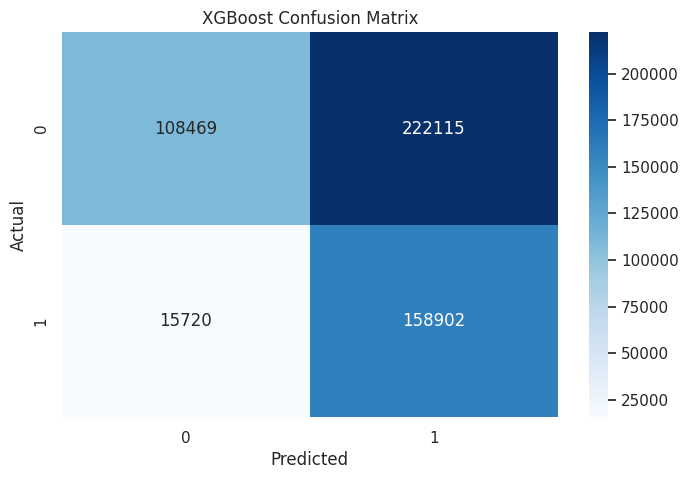


📈 ROC AUC: 0.7110808235199323


In [92]:
print("\n📊 Classification Report:")
print(classification_report(y, y_pred_class_new2))



cm = confusion_matrix(y, y_pred_class_new2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

print("\n📈 ROC AUC:", roc_auc_score(y, y_pred_proba_new2))

In [94]:
import joblib

# Example: Save to a specific folder
joblib.dump(best_xbgboost_model, r"D:\DEPI\project\final\best_xbgboost_model.pkl")




['D:\\DEPI\\project\\final\\best_xbgboost_model.pkl']